# Part B: Training and Using Word Embeddings

In [1]:
!pip install gensim
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 94.6 MB/s eta 0:00:00


In [2]:
# Import required libary

from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import nltk
from nltk.corpus import brown
import numpy as np

## Task B.1: Training Word2Vec
1. Load your chosen text corpus and perform basic preprocessing (tokenization, lowercasing).
2. Use the Gensim library to train a Word2Vec model (e.g., Skip-Gram architecture) on the corpus.
Hyperparameters: Set the embedding dimension (e.g., vector_size=100) and the window size.

In [4]:
nltk.download('brown')
sentences = brown.sents()

# Preprocessing: Lowercasing and tokenization
processed_sentences = [[word.lower() for word in sentence] for sentence in sentences]

# Train Word2Vec model
model = Word2Vec(sentences=processed_sentences, vector_size=100, window=5, min_count=1, workers=4, sg=1) # sg=1 for Skip-Gram

print(f"Model vocabulary size: {len(model.wv.index_to_key)}")

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!


Model vocabulary size: 49815


## Task B.2: Exploring Semantic Similarity Verify that the learned vectors capture meaning.
1. Use the trained model's .most_similar() method to find the top 5 words most similar to a seed word (e.g., "king," "python," or a domain-specific term from your corpus).
2. Demonstrate the famous analogy task using vector arithmetic: vector('king') - vector('man') + vector('woman') and display the most similar result (which should ideally be 'queen').


In [5]:
# 1. Find top 5 similar words to 'king'
seed_word = 'king'
if seed_word in model.wv.index_to_key:
    similar_words = model.wv.most_similar(seed_word, topn=5)
    print(f"Top 5 similar to '{seed_word}': {similar_words}")
else:
    print(f"'{seed_word}' not found in vocabulary.")

# 2. Demonstrate the analogy task: king - man + woman
analogy_result = model.wv.most_similar(positive=['king', 'woman'], negative=['man'], topn=1)
print(f"Analogy Result: {analogy_result}")

Top 5 similar to 'king': [('quiney', 0.932108461856842), ('lieutenant', 0.9290287494659424), ('pope', 0.9207062721252441), ('jane', 0.919104278087616), ('conrad', 0.9177300333976746)]
Analogy Result: [('jane', 0.8454739451408386)]


## Task B.3: Visualization and Comparison (Mini-Report) Embeddings live in high-dimensional space (e.g., 100D), making them impossible to view directly.
1. Select a set of 50 common words from your vocabulary.
2. Use a dimensionality reduction technique like t-SNE (from scikit-learn) to project the 100D vectors down to 2D.
3. Plot the 2D results using matplotlib. Analyze the plot: Do semantically related words cluster together?

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


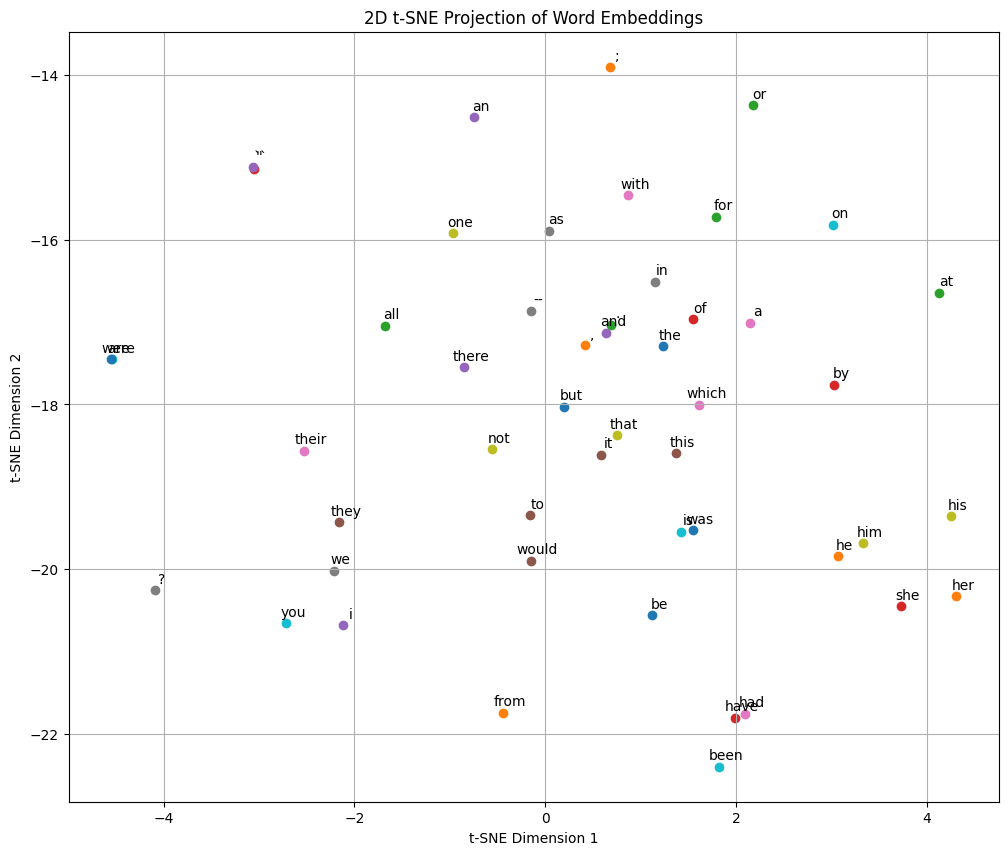

In [6]:
# 1. Select a set of 50 common words from your vocabulary
vocabulary_words = model.wv.index_to_key
selected_words = vocabulary_words[:50] # Taking the first 50 words as common words

# Get the vectors for the selected words
word_vectors = np.array([model.wv[word] for word in selected_words])

# 2. Use t-SNE to project the 100D vectors down to 2D
tsme = TSNE(n_components=2, random_state=42, perplexity=15, n_iter=3000)
reduced_vectors = tsme.fit_transform(word_vectors)

# 3. Plot the 2D results using matplotlib
plt.figure(figsize=(12, 10))
for i, word in enumerate(selected_words):
    plt.scatter(reduced_vectors[i, 0], reduced_vectors[i, 1])
    plt.annotate(word, (reduced_vectors[i, 0], reduced_vectors[i, 1]), textcoords="offset points", xytext=(5,5), ha='center')

plt.title('2D t-SNE Projection of Word Embeddings')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True)
plt.show()

- Look at the plot above. If the t-SNE projection is effective, words that are semantically similar should appear closer to each other.
- For example, you might observe clusters of verbs, nouns related to a specific topic, or words with similar connotations.
- However, t-SNE is a non-linear dimensionality reduction technique, and the absolute distances in the 2D plot might not perfectly reflect the high-dimensional distances. It's primarily for visual exploration of local neighborhoods.